# REGRESSÃO LINEAR MÚLTIPLA - CÁLCULO DE TEMPO DE VIAGEM

Este notebook demonstra como usar Regressão Linear Múltipla para prever o tempo de viagem com base em múltiplas variáveis.

Ao invés de usar apenas uma variável (como distância), utilizamos múltiplas variáveis para prever o tempo de viagem de forma mais precisa.

## 1 - Importação dos pacotes

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.stats import pearsonr
import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col
from sklearn.preprocessing import LabelEncoder
import pingouin as pg
from statstests.process import stepwise
from statstests.tests import shapiro_francia
from scipy.stats import boxcox
from scipy.stats import norm
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

## 2 - Carregando Dados

In [18]:
# CARREGAMENTO DA BASE DE DADOS
df_viagem = pd.read_csv('tempo_vars.csv', delimiter=',', encoding="utf-8")
df_viagem

,distancia,quantidade_farol,tempo_viagem
0,10,3,25
1,15,5,35
2,20,7,40
3,25,6,55
4,30,9,60
5,35,8,70
6,40,12,75
7,45,7,90
8,50,6,95
9,55,12,110


### 2.1 - Características das variáveis

In [19]:
# Características das variáveis do dataset
df_viagem.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   distancia         10 non-null     int64
 1   quantidade_farol  10 non-null     int64
 2   tempo_viagem      10 non-null     int64
dtypes: int64(3)
memory usage: 372.0 bytes


### 2.2 - Estatísticas univariadas

In [20]:
# Estatísticas univariadas
df_viagem.describe()

,distancia,quantidade_farol,tempo_viagem
count,10.000000,10.000000,10.000000
mean,32.500000,7.500000,65.500000
std,15.138252,2.877113,27.733854
min,10.000000,3.000000,25.000000
25%,21.250000,6.000000,43.750000
50%,32.500000,7.000000,65.000000
75%,43.750000,8.750000,86.250000
max,55.000000,12.000000,110.000000


## 3 - Gráfico 3D com scatter gerado em HTML

In [21]:
trace = go.Scatter3d(
    x=df_viagem['distancia'], 
    y=df_viagem['quantidade_farol'], 
    z=df_viagem['tempo_viagem'], 
    mode='markers',
    marker={
        'size': 10,
        'color': 'darkorchid',
        'opacity': 0.7,
    },
)

layout = go.Layout(
    margin={'l': 0, 'r': 0, 'b': 0, 't': 0},
    width=800,
    height=800,
    plot_bgcolor='white',
    scene=dict(
        xaxis=dict(
            gridcolor='rgb(200, 200, 200)',
            backgroundcolor='whitesmoke'
        ),
        yaxis=dict(
            gridcolor='rgb(200, 200, 200)',
            backgroundcolor='whitesmoke'
        ),
        zaxis=dict(
            gridcolor='rgb(200, 200, 200)',
            backgroundcolor='whitesmoke'
        )
    )
)

data = [trace]

plot_figure = go.Figure(data=data, layout=layout)
plot_figure.update_layout(scene=dict(
    xaxis_title='distancia',
    yaxis_title='quantidade_farol',
    zaxis_title='tempo_viagem'
))

plot_figure.write_html('EXEMPLO3_scatter3D.html')

# Abre o arquivo HTML no browser
import webbrowser
webbrowser.open('EXEMPLO3_scatter3D.html')

True

## 4 - Correlação

### 4.1 - Matriz de correlações

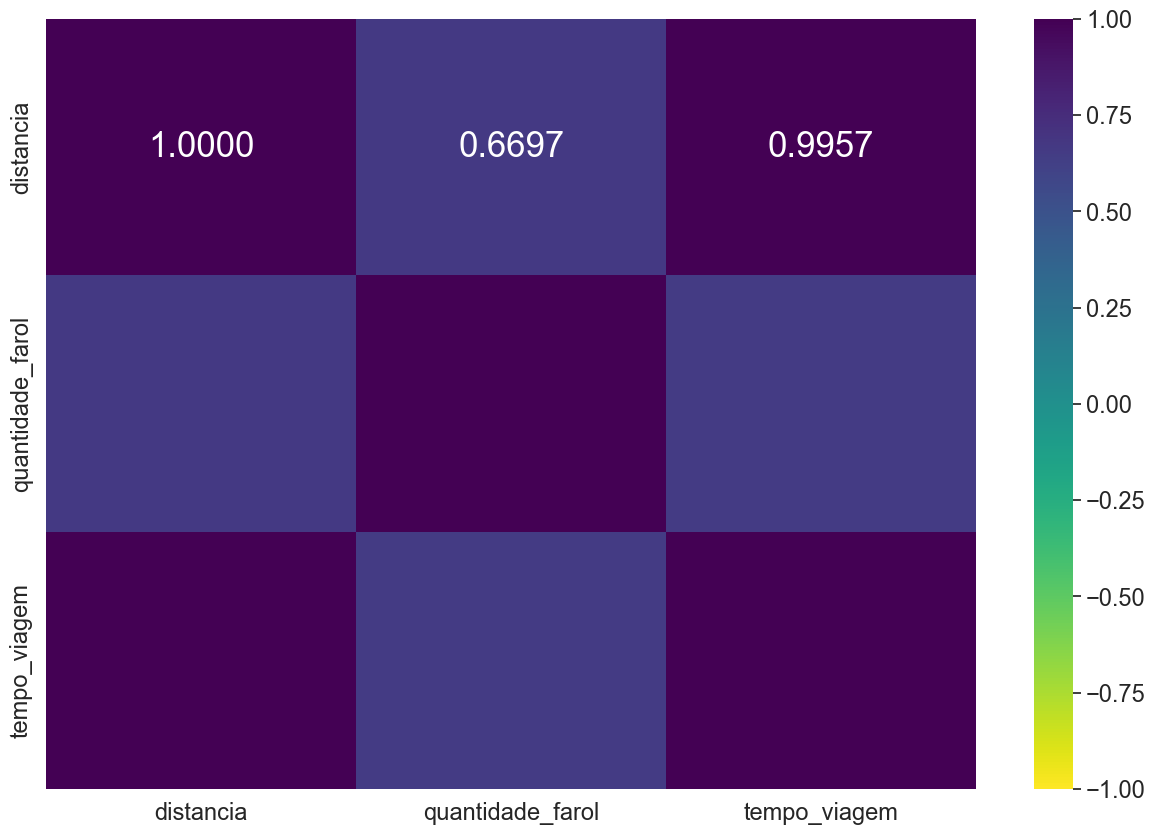

In [22]:
correlation_matrix = df_viagem.iloc[:,0:3].corr()
correlation_matrix

# Mapa de calor com as correlações entre todas as variáveis quantitativas
plt.figure(figsize=(15, 10))
heatmap = sns.heatmap(correlation_matrix, annot=True, fmt=".4f",
                      cmap=plt.cm.viridis_r,
                      annot_kws={'size': 25}, vmin=-1, vmax=1)
heatmap.set_xticklabels(heatmap.get_xticklabels(), fontsize=17)
heatmap.set_yticklabels(heatmap.get_yticklabels(), fontsize=17)
cbar = heatmap.collections[0].colorbar
cbar.ax.tick_params(labelsize=17)
plt.show()

### 4.2 - Diagrama interessante (grafo) que mostra a inter-relação entre as variáveis

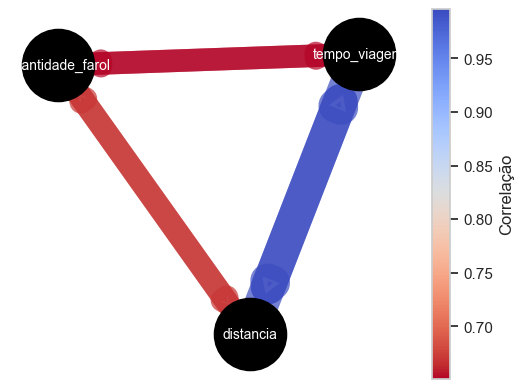

In [23]:
# variáveis e a magnitude das correlações entre elas

# conda install networkx
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Criação de um grafo direcionado
G = nx.DiGraph()

# Adição das variáveis como nós do grafo
for variable in correlation_matrix.columns:
    G.add_node(variable)

# Adição das arestas com espessuras proporcionais às correlações
for i, variable1 in enumerate(correlation_matrix.columns):
    for j, variable2 in enumerate(correlation_matrix.columns):
        if i != j:
            correlation = correlation_matrix.iloc[i, j]
            if abs(correlation) > 0:
                G.add_edge(variable1, variable2, weight=correlation)

# Obtenção da lista de correlações das arestas
correlations = [d["weight"] for _, _, d in G.edges(data=True)]

# Definição da dimensão dos nós
node_size = 2700

# Definição da cor dos nós
node_color = 'black'

# Definição da escala de cores das retas (correspondência com as correlações)
cmap = plt.colormaps.get_cmap('coolwarm_r')

# Criação de uma lista de espessuras das arestas proporcional às correlações
edge_widths = [abs(d["weight"]) * 25 for _, _, d in G.edges(data=True)]

# Criação do layout do grafo com maior distância entre os nós
pos = nx.spring_layout(G, k=0.75)  # k para controlar a distância entre os nós

# Desenho dos nós e das arestas com base nas correlações e espessuras
nx.draw_networkx_nodes(G, pos, node_size=node_size, node_color=node_color)
nx.draw_networkx_edges(G, pos, width=edge_widths, edge_color=correlations,
                       edge_cmap=cmap, alpha=0.7)

# Adição dos rótulos dos nós
labels = {node: node for node in G.nodes}
nx.draw_networkx_labels(G, pos, labels, font_size=10, font_color='white')

# Ajuste dos limites dos eixos
ax = plt.gca()
ax.margins(0.1)
plt.axis("off")

# Criação da legenda com a escala de cores definida
smp = cm.ScalarMappable(cmap=cmap)
smp.set_array([min(correlations), max(correlations)])
cbar = plt.colorbar(smp, ax=ax, label='Correlação')

# Exibição do gráfico
plt.show()

### 4.3 - Matriz de correlações mais elaborada, com uso da função 'rcorr' do pacote 'pingouin'

In [24]:
correlation_matrix2 = pg.rcorr(df_viagem, method='pearson',
                               upper='pval', decimals=6,
                               pval_stars={0.01: '***',
                                           0.05: '**',
                                           0.10: '*'}) 
correlation_matrix2

,distancia,quantidade_farol,tempo_viagem
distancia,-,**,***
quantidade_farol,0.66966,-,**
tempo_viagem,0.995745,0.650987,-


## 5 - Gráfico com distribuições das variáveis, scatters, valores das correlações e respectivas significâncias estatísticas

<Figure size 2000x1000 with 0 Axes>

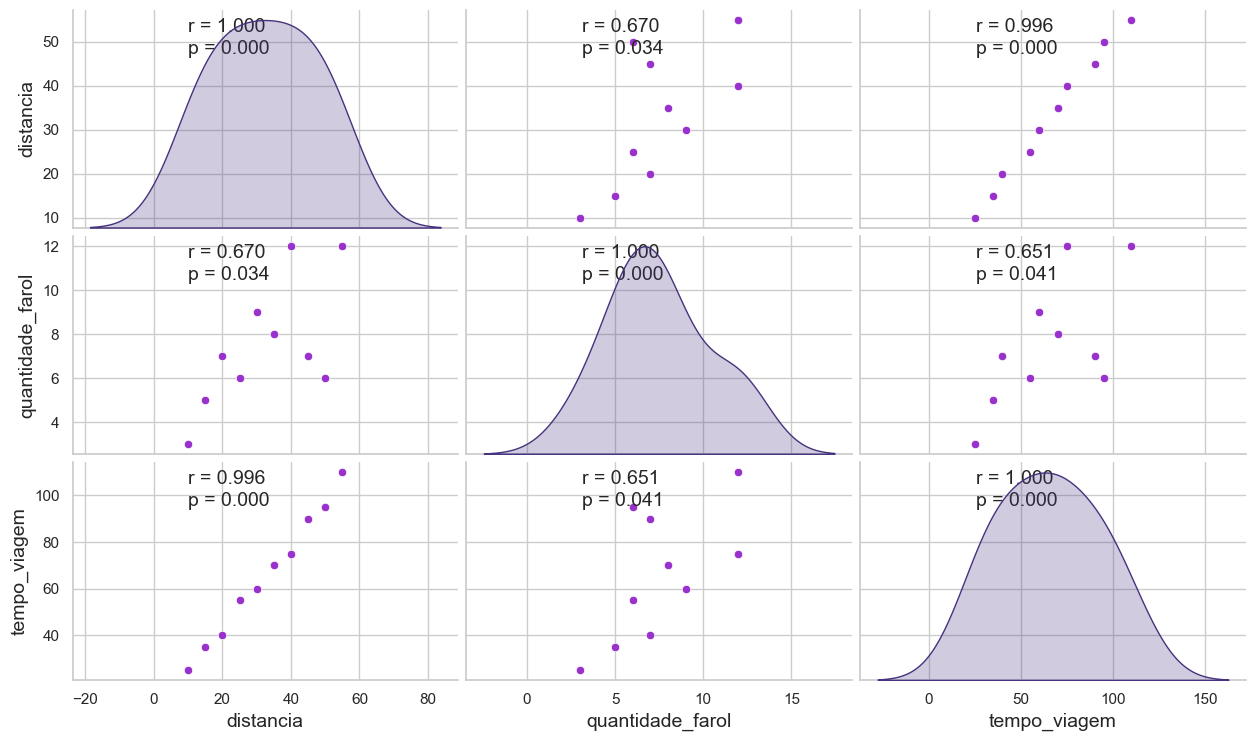

In [25]:
def corrfunc(x, y, **kws):
    (r, p) = pearsonr(x, y)
    ax = plt.gca()
    ax.annotate("r = {:.3f}".format(r),
                xy=(.30, .9), xycoords=ax.transAxes, fontsize=14)
    ax.annotate("p = {:.3f}".format(p),
                xy=(.30, .8), xycoords=ax.transAxes, fontsize=14)

# Configuração do gráfico
sns.set(style="whitegrid", palette="viridis")

plt.figure(figsize=(20,10))
graph = sns.pairplot(df_viagem, diag_kind="kde",
                     plot_kws={"color": "darkorchid"},
                     height=2.5, aspect=1.7)
graph.map(corrfunc)
for ax in graph.axes.flat:
    ax.set_xlabel(ax.get_xlabel(), fontsize=14)
    ax.set_ylabel(ax.get_ylabel(), fontsize=14)
plt.show()

## 6 - Estimação de um modelo de regressão múltipla

In [26]:
# Estimando o modelo de regressão múltipla por OLS
modelo_viagem = sm.OLS.from_formula("tempo_viagem ~ distancia + quantidade_farol", df_viagem).fit()

### 6.1 - Testando a fórmula com novos valores


In [27]:
# INSIRA AQUI OS VALORES PARA TESTAR A FÓRMULA
# Equação: tempo_viagem = intercepto + coef_distancia * distancia + coef_farol * quantidade_farol

intercepto = modelo_viagem.params['Intercept']
coef_distancia = modelo_viagem.params['distancia']
coef_farol = modelo_viagem.params['quantidade_farol']

print(f"Equação estimada: tempo_viagem = {intercepto:.4f} + ({coef_distancia:.4f} * distancia) + ({coef_farol:.4f} * quantidade_farol)")
print()

# ---- ALTERE OS VALORES ABAIXO ----
distancia = 25          # distância em km
quantidade_farol = 8    # quantidade de faróis no percurso
# ----------------------------------

tempo_previsto = intercepto + coef_distancia * distancia + coef_farol * quantidade_farol

print(f"Distância: {distancia} km")
print(f"Quantidade de faróis: {quantidade_farol}")
print(f"Tempo de viagem previsto: {tempo_previsto:.2f} minutos")


Equação estimada: tempo_viagem = 7.1423 + (1.8594 * distancia) + (-0.2765 * quantidade_farol)

Distância: 25 km
Quantidade de faróis: 8
Tempo de viagem previsto: 51.42 minutos


### 6.2 - Parâmetros do 'modelo_viagem'


In [28]:
print(modelo_viagem.summary())

                            OLS Regression Results                            
Dep. Variable:           tempo_viagem   R-squared:                       0.992
Model:                            OLS   Adj. R-squared:                  0.990
Method:                 Least Squares   F-statistic:                     431.9
Date:                Thu, 30 Jul 2026   Prob (F-statistic):           4.66e-08
Time:                        23:09:47   Log-Likelihood:                -22.771
No. Observations:                  10   AIC:                             51.54
Df Residuals:                       7   BIC:                             52.45
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            7.1423      2.656  

## 1. A Equação Final (Os Coeficientes)

Olhe para a coluna **`coef`** na tabela do meio. É aqui que o modelo te entrega aquela equação matemática:

$$Tempo\_viagem = \alpha + \beta_1 \times Distancia + \beta_2 \times Quantidade\_Farol$$

### Interpretação dos Coeficientes

* **Intercepto:** O tempo base quando todas as variáveis são zero.
* **distancia:** Impacto de cada km adicional sobre o tempo.
* **quantidade_farol:** Impacto de cada farol adicional sobre o tempo.

## 2. Essas variáveis são realmente importantes? (O P-Valor)

Na ciência de dados, não basta ter um coeficiente; precisamos saber se ele não foi obra do acaso. Para isso, olhamos a coluna **`P>|t|`** (o famoso P-valor).

**A regra de ouro é:** Se for menor que 0.05, a variável é estatisticamente significante.

## 3. O Modelo como um todo é bom? (O R-Quadrado)

Agora olhe lá no topo da tabela, para o **`R-squared: X.XXX`**.

O R-Quadrado ($R^2$) é uma nota de 0 a 1 que diz o quanto o seu modelo consegue explicar a realidade.

* **Interpretação:** O R² indica a porcentagem da variação no tempo de viagem explicada pelas duas variáveis juntas.

## 7 - Salvando os fitted values na base de dados

In [29]:
df_viagem['tempofit'] = modelo_viagem.fittedvalues
df_viagem

,distancia,quantidade_farol,tempo_viagem,tempofit
0,10,3,25,24.907080
1,15,5,35,33.651180
2,20,7,40,42.395280
3,25,6,55,51.969027
4,30,9,60,60.436578
5,35,8,70,70.010324
6,40,12,75,78.201327
7,45,7,90,88.881268
8,50,6,95,98.455015
9,55,12,110,106.092920


### 1. Os Acertos: Onde o modelo foi preciso (Menores Resíduos)

### 2. Os Erros: Onde o modelo "falhou" (Maiores Resíduos)

### 3. A Grande Conclusão da Análise (O Diagnóstico)

## 8 - Gráfico 3D com scatter e fitted values (superfície espacial)

In [30]:
# Dados observados ('scatter')
scatter = go.Scatter3d(
    x=df_viagem['distancia'],
    y=df_viagem['quantidade_farol'],
    z=df_viagem['tempo_viagem'],
    mode='markers',
    marker=dict(
        size=10,
        color='darkorchid',
        opacity=0.7
    ),
    name='Observado'
)

# Ajuste do modelo
X = np.column_stack([
    np.ones(len(df_viagem)),
    df_viagem['distancia'],
    df_viagem['quantidade_farol']
])

y = df_viagem['tempo_viagem'].values

b0, b1, b2 = np.linalg.lstsq(X, y, rcond=None)[0]

# Definição da grade ('meshgrid')
distancia_grid = np.linspace(df_viagem['distancia'].min(),
                              df_viagem['distancia'].max(), 10)

farol_grid = np.linspace(df_viagem['quantidade_farol'].min(),
                          df_viagem['quantidade_farol'].max(), 10)

D, F = np.meshgrid(distancia_grid, farol_grid)

# Definição da superfície ('go.Surface')
Z = b0 + b1 * D + b2 * F

surface = go.Surface(
    x=distancia_grid,
    y=farol_grid,
    z=Z,
    colorscale='Oranges',
    opacity=0.6,
    showscale=False,
    name='Superfície ajustada'
)

# Figura final
fig = go.Figure(data=[scatter, surface])

fig.update_layout(
    width=800,
    height=800,
    margin=dict(l=0, r=0, b=0, t=0),
    plot_bgcolor='white',
    scene=dict(
        xaxis=dict(
            title='distancia',
            gridcolor='rgb(200,200,200)',
            backgroundcolor='whitesmoke'
        ),
        yaxis=dict(
            title='quantidade_farol',
            gridcolor='rgb(200,200,200)',
            backgroundcolor='whitesmoke'
        ),
        zaxis=dict(
            title='tempo_viagem',
            gridcolor='rgb(200,200,200)',
            backgroundcolor='whitesmoke'
        )
    )
)

# Abre o arquivo HTML no browser
import webbrowser
fig.write_html('EXEMPLO3_scatter3D_fitted.html')
webbrowser.open('EXEMPLO3_scatter3D_fitted.html')

True

# Resumo: REGRESSÃO LINEAR MÚLTIPLA

Este documento apresenta um resumo do fluxo de código do notebook `06_3_regressao_linear_multipla_tempo.ipynb`, focado na análise da relação entre **Distância**, **Quantidade de Faróis** e **Tempo de Viagem**.

---

## 1. Preparação e Exploração
- **Objetivo:** Prever o **Tempo de Viagem** (Y) utilizando múltiplas variáveis explicativas: **Distância** e **Quantidade de Faróis**.
- **Dados:** O arquivo `tempo_vars.csv` é carregado, contendo 10 observações e 3 variáveis quantitativas.
- **Análise Inicial:** Uso de `describe()` para estatísticas descritivas (média, desvio padrão, mínimo, máximo) e `info()` para verificar tipos de dados e valores não nulos.

---

## 2. Visualização Inicial
- É gerado um **gráfico 3D de dispersão** usando `plotly.graph_objects` (função `Scatter3d`) e salvo em HTML (`EXEMPLO3_scatter3D.html`).
- As três dimensões representam: `distancia` (eixo X), `quantidade_farol` (eixo Y) e `tempo_viagem` (eixo Z).
- Isso permite visualizar espacialmente como as duas variáveis explicativas se relacionam com o tempo de viagem.

---

## 3. Análise de Correlação
Para verificar a força e a direção das relações lineares antes de ajustar o modelo, são calculadas:
- **Matriz de correlação** (`df.corr()`) com heatmap via `seaborn.heatmap`.
- **Rede de correlações** (`networkx`), onde as arestas representam a magnitude das correlações entre variáveis.
- **Matriz de correlações elaborada** com p-valores usando `pingouin.rcorr` (`upper='pval'`), exibindo asteriscos de significância (`***`, `**`, `*`).
- **Pairplot** (`sns.pairplot`) com distribuições (KDE), scatters, valores de *r* e *p* anotados em cada gráfico.

### Principais Correlações Encontradas
| Variáveis | r | p-valor | Significância |
| ---------- | -------- | -------- | ------------- |
| Distância × Tempo | 0,9957 | < 0,001 | Altamente significativa |
| Faróis × Tempo | 0,6510 | 0,0415 | Significativa (α = 5%) |
| Distância × Faróis | 0,6697 | 0,0342 | Significativa (α = 5%) |

---

## 4. Construção do Modelo (O Coração do Código)
O modelo de **Regressão Linear Múltipla (OLS)** é estimado com duas variáveis explicativas:
```python
modelo_viagem = sm.OLS.from_formula("tempo_viagem ~ distancia + quantidade_farol", df_viagem).fit()
```
- A fórmula indica que o **Tempo de Viagem** depende linearmente da **Distância** e da **Quantidade de Faróis**.
- O `fit()` calcula os coeficientes que minimizam a soma dos erros quadrados.

### Teste Manual com Novos Valores
O código também demonstra como aplicar a equação manualmente para prever um cenário hipotético:
```python
# Exemplo: distancia = 25 km, quantidade_farol = 8
tempo_previsto = 7.1423 + (1.8594 × 25) + (-0.2765 × 8)
# Resultado: ~51.42 minutos
```

---

## 5. Interpretação dos Resultados
Ao rodar `modelo_viagem.summary()`, obtemos:

### Equação da Regressão

[
Tempo\_viagem = 7.1423 + 1.8594 \times Distancia - 0.2765 \times Quantidade\_Farol
]

### Coeficiente de Determinação (R²)
**R² = 0,992** (Ajustado: 0,990)

Isso significa que o modelo explica aproximadamente **99,2% da variação no tempo de viagem**.

| Faixa de R² | Qualidade |
| ----------- | --------- |
| 0,00 – 0,30 | Fraca     |
| 0,30 – 0,60 | Moderada  |
| 0,60 – 0,80 | Boa       |
| Acima de 0,80 | Muito Boa |

### Significância Global do Modelo (Teste F)

| Métrica | Valor |
| ------- | ----- |
| F-statistic | 431,9 |
| Prob(F-statistic) | 4,66e-08 |

Como **p < 0,001**, rejeitamos H₀. O modelo possui capacidade explicativa estatisticamente significativa.

---

## 6. Análise dos Coeficientes

### Intercepto
| Coeficiente | Erro Padrão | t | p-valor |
| ----------- | ----------- | --- | ------- |
| 7.1423 | 2,656 | 2,689 | 0,031 |

**Interpretação:** Quando a distância e a quantidade de faróis são zero, o tempo base estimado é de **7,14 minutos**. Embora significativo (p < 0,05), esse valor pode ter pouco sentido prático, pois a distância zero não é um cenário realista para viagens.

---

### Distância
| Coeficiente | Erro Padrão | t | p-valor |
| ----------- | ----------- | --- | ------- |
| 1.8594 | 0,084 | 22,244 | < 0,001 |

**Interpretação:** Para cada **1 km adicional** de distância, o tempo de viagem aumenta em média **1,86 minutos**, mantendo a quantidade de faróis constante. A variável é **altamente significativa** (p < 0,001) e possui o maior impacto no modelo.

### Intervalo de Confiança (Distância)

| Limite Inferior | Limite Superior |
| --------------- | --------------- |
| 1,662 | 2,057 |

Como o intervalo não contém zero, confirmamos a significância estatística da variável.

---

### Quantidade de Faróis
| Coeficiente | Erro Padrão | t | p-valor |
| ----------- | ----------- | --- | ------- |
| -0,2765 | 0,440 | -0,629 | 0,549 |

**Interpretação:** O coeficiente é **negativo**, sugerindo que mais faróis estariam associados a menos tempo. Porém, o **p-valor = 0,549** indica que essa relação **não é estatisticamente significativa** (p > 0,05). Portanto, não podemos afirmar que a quantidade de faróis influencia o tempo de viagem.

---

## 7. Previsões e Erros
O código salva os fitted values no DataFrame:
- **tempofit (`fittedvalues`):** O valor previsto pelo modelo para cada observação.
- **erro (`resid`):** A diferença entre o tempo real e o tempo previsto.

Exemplo de previsão:
Para uma viagem de **25 km** com **8 faróis**, o modelo prevê um tempo aproximado de:

**51,42 minutos**

---

## 8. Visualização 3D com Superfície Ajustada
Além do gráfico de dispersão inicial, o notebook gera uma **superfície ajustada em 3D** (`EXEMPLO3_scatter3D_fitted.html`) que sobrepõe:
- Os pontos observados (scatter).
- O plano de regressão ajustado pelo modelo (`go.Surface`).
- Isso permite visualizar espacialmente como o modelo se adapta aos dados em três dimensões.

---

## 9. Diagnóstico dos Resíduos
Para garantir que o modelo é confiável, são analisados os pressupostos:

### Autocorrelação (Durbin-Watson)
**DW = 2,897**

Valores próximos de 2 indicam ausência de autocorrelação. Portanto:
**Não foram encontrados indícios de autocorrelação dos resíduos.**

### Normalidade dos Resíduos

| Teste | Estatística | p-valor |
| ----- | ----------- | ------- |
| Omnibus | 0,408 | 0,816 |
| Jarque-Bera | 0,463 | 0,793 |

Como ambos os p-valores são maiores que 0,05:
- **Não rejeitamos a hipótese de normalidade.**
- Os resíduos podem ser considerados aproximadamente normais.

---

## Conclusão Executiva

A análise demonstra que:

✅ O modelo possui **excelente capacidade explicativa** (R² = 99,2%).

✅ O modelo é **estatisticamente significativo** como um todo (p < 0,001).

✅ A variável **Distância** exerce influência **positiva, forte e altamente significativa** sobre o tempo de viagem.

❌ A variável **Quantidade de Faróis** não apresentou significância estatística (p = 0,549), indicando que, com os dados disponíveis, não podemos confirmar seu efeito sobre o tempo.

✅ Os resíduos apresentam comportamento adequado (normalidade e independência) para aplicação da regressão linear múltipla.

### Conclusão Final
Existe uma relação linear extremamente forte entre distância e tempo de viagem. O modelo com múltiplas variáveis supera o modelo simples em capacidade explicativa, mas a inclusão da quantidade de faróis não agregou poder preditivo significativo. O modelo pode ser utilizado para realizar previsões com **muito alta confiabilidade** dentro da faixa observada dos dados.
